# Run cells from AllenDB

In [1]:
import os, sys, json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


def _find_scp_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for cand in (start, *start.parents):
        if (cand / 'modules_local').is_dir() and (cand / 'run_pipeline.py').is_file():
            return cand
    raise FileNotFoundError(
        f'Could not locate SCP repo root from {start}. Expected modules_local/ and run_pipeline.py.'
    )


def _resolve_external_repo(
    repo_name: str,
    marker_rel: Path,
    env_vars: tuple[str, ...],
    repo_root: Path,
) -> Path:
    candidates: list[Path] = []
    for var in env_vars:
        raw = os.environ.get(var)
        if raw:
            candidates.append(Path(raw).expanduser())

    candidates.extend(
        [
            repo_root.parent / 'mods' / repo_name,
            repo_root / 'mods' / repo_name,
            Path.home() / 'mods' / repo_name,
            (Path.cwd() / '..' / 'mods' / repo_name).resolve(),
            (Path.cwd() / 'mods' / repo_name).resolve(),
        ]
    )

    seen: set[Path] = set()
    for cand in candidates:
        try:
            resolved = cand.resolve()
        except Exception:
            resolved = cand
        if resolved in seen:
            continue
        seen.add(resolved)
        if (resolved / marker_rel).is_file():
            return resolved

    raise FileNotFoundError(
        f"{repo_name} repo not found. Set {', '.join(env_vars)} or place it at ../mods/{repo_name} relative to SCP."
    )


# Ensure SCP repo root is importable for legacy modules_old notebooks
repo_root = _find_scp_repo_root()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

# Import legacy SCP modules used by this notebook
from modules_old import build_cell
from modules_old import run_sim

# Import ACT modules (read-only external dependency)
act_path = _resolve_external_repo(
    repo_name='ACT',
    marker_rel=Path('act') / 'passive.py',
    env_vars=('SCP_ACT_PATH', 'ACT_PATH', 'ACT_ROOT'),
    repo_root=repo_root,
)
if str(act_path) not in sys.path:
    sys.path.append(str(act_path))

from act.passive import ACTPassiveModule


--No graphics will be displayed.


# Download Cell

### Set Parameters

In [2]:
cell_name = 'SST' #SST, SST_0, PV, PN

if os.path.isdir(f"cells/{cell_name}"): os.chdir(f"cells/{cell_name}") #else: create?

# http://celltypes.brain-map.org/mouse/experiment/electrophysiology/'specimen_id'
spec_ids = {'SST': 485466109, 'PV': 484635029}
specimen_id = spec_ids[cell_name] #SST 476686112, SST 485466109, PV 484635029, 571709783
model_type = 'perisomatic' #or 'all active'

tunes_dir = 'tunes'
model_dir = 'seg_tuned'

In [3]:
from pathlib import Path
import json

cfg_path = Path(tunes_dir) / model_dir / "cell_configs" / "sim_config.json"
if not cfg_path.is_file():
    cfg_path = Path(tunes_dir) / model_dir / "sim_config.json"
if not cfg_path.is_file():
    cfg_path = Path(f"cells/{cell_name}") / tunes_dir / model_dir / "cell_configs" / "sim_config.json"
if not cfg_path.is_file():
    cfg_path = Path(f"cells/{cell_name}") / tunes_dir / model_dir / "sim_config.json"
if cfg_path.is_file():
    sim_cfg_preview = json.loads(cfg_path.read_text())
    if 'specimen_id' in sim_cfg_preview:
        specimen_id = sim_cfg_preview['specimen_id']
    if 'model_type' in sim_cfg_preview:
        model_type = sim_cfg_preview['model_type']
    if 'soma_diam_multiplier' in sim_cfg_preview:
        soma_diam_multiplier = sim_cfg_preview['soma_diam_multiplier']


### Download Cell (if not already downloaded)

In [4]:
from pathlib import Path

bundle_dir = Path(tunes_dir) / model_dir
required_paths = [
    bundle_dir / "manifest.json",
    bundle_dir / "modfiles",
]
missing = [str(p) for p in required_paths if not p.exists()]
if missing:
    missing_text = "\n".join(missing)
    raise FileNotFoundError(
        f"Missing required local cell bundle files:\n{missing_text}\n"
        "Prepare/download the bundle in Step 0, then rerun this notebook."
    )

print(f"Using existing local model bundle: {bundle_dir.resolve()}")


Using existing local model bundle: /home/hrbncv/SCP/cells/SST/tunes/seg_tuned


### Compile Modfiles

In [5]:
os.chdir(f'{tunes_dir}/{model_dir}')

# update_modfiles = None # or path/link to modfiles TODO
# if update_modfiles is not None:
#     !git clone update_modfiles

# if already compiled then lets delete the folder and force a recompile
if os.path.isdir('modfiles/x86_64'):
    os.system("rm -rf modfiles/x86_64")
# compile the mod files
if not os.path.isdir("modfiles/x86_64"):
    # !nrnivmodl modfiles > /dev/null 2>&1
    os.chdir('modfiles')
    os.system("nrnivmodl")
    os.chdir("..")


from neuron import h
h.load_file("stdrun.hoc")  # Required to use h.run()
h.nrn_load_dll("modfiles/x86_64/.libs/libnrnmech.so")

/home/hrbncv/SCP/cells/SST/tunes/seg_tuned/modfiles
Mod files: "./AMPA_NMDA_STP.mod" "./CaDynamics.mod" "./Ca_HVA.mod" "./Ca_LVA.mod" "./GABA_A.mod" "./GABA_A_STP.mod" "./Ih.mod" "./Im_v2.mod" "./Kd.mod" "./K_T.mod" "./Kv2like.mod" "./Kv3_1.mod" "./Nap.mod" "./NaTa.mod" "./SK.mod" "./vecstim.mod"

Creating 'x86_64' directory for .o files.

 -> Compiling mod_func.cpp
 -> NMODL ../AMPA_NMDA_STP.mod
 -> NMODL ../CaDynamics.mod
 -> NMODL ../Ca_HVA.mod
 -> NMODL ../Ca_LVA.mod
 -> NMODL ../GABA_A.mod
 -> NMODL ../GABA_A_STP.mod
 -> NMODL ../Ih.mod
 -> NMODL ../Im_v2.mod
 -> NMODL ../Kd.mod
 -> NMODL ../K_T.mod
 -> NMODL ../Kv2like.mod
 -> NMODL ../Kv3_1.mod
 -> NMODL ../Nap.mod
 -> NMODL ../NaTa.mod
 -> NMODL ../SK.mod
 -> NMODL ../vecstim.mod
 -> Compiling AMPA_NMDA_STP.c
 -> Compiling CaDynamics.c
 -> Compiling Ca_HVA.c
 -> Compiling Ca_LVA.c
 -> Compiling GABA_A.c
 -> Compiling GABA_A_STP.c
 -> Compiling Ih.c
 -> Compiling Im_v2.c
 -> Compiling Kd.c
 -> Compiling K_T.c
 -> Compiling Kv2li

Translating AMPA_NMDA_STP.mod into /home/hrbncv/SCP/cells/SST/tunes/seg_tuned/modfiles/x86_64/AMPA_NMDA_STP.c
Translating CaDynamics.mod into /home/hrbncv/SCP/cells/SST/tunes/seg_tuned/modfiles/x86_64/CaDynamics.c
Translating Ca_HVA.mod into /home/hrbncv/SCP/cells/SST/tunes/seg_tuned/modfiles/x86_64/Ca_HVA.c
Thread Safe
Thread Safe
Thread Safe
Translating Ca_LVA.mod into /home/hrbncv/SCP/cells/SST/tunes/seg_tuned/modfiles/x86_64/Ca_LVA.c
Thread Safe
Translating GABA_A.mod into /home/hrbncv/SCP/cells/SST/tunes/seg_tuned/modfiles/x86_64/GABA_A.c
Translating GABA_A_STP.mod into /home/hrbncv/SCP/cells/SST/tunes/seg_tuned/modfiles/x86_64/GABA_A_STP.c
Translating Ih.mod into /home/hrbncv/SCP/cells/SST/tunes/seg_tuned/modfiles/x86_64/Ih.c
Thread Safe
Thread Safe
Thread Safe
Translating Im_v2.mod into /home/hrbncv/SCP/cells/SST/tunes/seg_tuned/modfiles/x86_64/Im_v2.c
Thread Safe
Translating Kd.mod into /home/hrbncv/SCP/cells/SST/tunes/seg_tuned/modfiles/x86_64/Kd.c
Translating Kv2like.mod into

Successfully created x86_64/special


1.0

# Build the cell

In [6]:
soma_diam_multis = {'SST':6, 'SST':8, 'PV':6}
soma_diam_multiplier = soma_diam_multis[cell_name] #SST 6, SST 8, PV 6
if 'sim_cfg_preview' in globals():
    soma_diam_multiplier = sim_cfg_preview.get('soma_diam_multiplier', soma_diam_multiplier)

from modules_local.load_cell import load_cell as load_cell_local


def _resolve_cell_config_for_legacy_notebook(cell_name: str, fallback_soma: float = 1.0):
    """Use cell_config.json as canonical, with minimal fallback for legacy fields."""
    cell_cfg_path = Path('cell_configs') / 'cell_config.json'
    if cell_cfg_path.is_file():
        cell_config = json.loads(cell_cfg_path.read_text())
    else:
        cell_config = {}
    if not isinstance(cell_config, dict):
        cell_config = {}

    cell_config.setdefault('cell_name', cell_name)
    paths = cell_config.setdefault('paths', {})
    paths.setdefault('manifest', 'manifest.json')

    tuning = cell_config.setdefault('tuning', {})
    if 'soma_diam_multiplier' not in tuning:
        if 'soma_diam_multiplier' in globals():
            tuning['soma_diam_multiplier'] = float(soma_diam_multiplier)
        else:
            tuning['soma_diam_multiplier'] = float(fallback_soma)

    # Back-compat fallback (only fill missing keys from sim_config preview)
    if 'sim_cfg_preview' in globals() and isinstance(sim_cfg_preview, dict):
        if 'specimen_id' not in cell_config and 'specimen_id' in sim_cfg_preview:
            cell_config['specimen_id'] = sim_cfg_preview['specimen_id']
        if 'model_type' not in cell_config and 'model_type' in sim_cfg_preview:
            cell_config['model_type'] = sim_cfg_preview['model_type']

    return cell_config


def _build_cell_legacy_compatible(cell_config: dict):
    """Build via modules_local.load_cell while exposing legacy attributes."""
    loaded = load_cell_local(cell_config)

    # modules_old.run_sim expects these attributes on the cell object
    if not hasattr(loaded, 'soma'):
        loaded.soma = loaded.h.soma
    if not hasattr(loaded, 'dend'):
        loaded.dend = list(loaded.h.dend) if hasattr(loaded.h, 'dend') else []
    if not hasattr(loaded, 'apic'):
        loaded.apic = list(loaded.h.apic) if hasattr(loaded.h, 'apic') else []
    if not hasattr(loaded, 'axon'):
        loaded.axon = list(loaded.h.axon) if hasattr(loaded.h, 'axon') else []

    return loaded


cell_config_for_build = _resolve_cell_config_for_legacy_notebook(cell_name, fallback_soma=float(soma_diam_multiplier))
cell = _build_cell_legacy_compatible(cell_config_for_build)

sect = cell.soma[0]
seg = 0.5
print(f"{sect}: A={round(sect(seg).area(),2)} | D={round(sect.diam)} | L={round(sect.L)}")



/home/hrbncv/miniconda3/envs/BMTK-py311/lib/python3.11/site-packages/allensdk/model/biophys_sim/config.py:38: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename  # @UnresolvedImport


Loaded Allen cell for 'SST' from manifest.json, soma_diam_multiplier=8.0, Vinit=-85.0
soma[0]: A=4591.3 | D=108 | L=14


# Passive properties

In [7]:
# Soma area from the previous cell
computed_soma_area = cell.soma[0](0.5).area() * 1e-8 #(cm2)
# User-provided desired properties
user_provided_Rin = 195.4 * 10e6    # (to Ohm from MOhm)
user_provided_tau = 15.6 * 1e-3     # (to s from ms)
user_provided_Vrest = -65.75        # (mV)
spps = ACTPassiveModule.compute_spp(user_provided_Rin, computed_soma_area, user_provided_tau, user_provided_Vrest)
print(spps)

SettablePassiveProperties(Cm=0.17388579373693497, g_bar_leak=1.1146525239547114e-05, e_rev_leak=-65.75, g_bar_h=None)


### set simulation parameters

Loaded Allen cell for 'SST' from manifest.json, soma_diam_multiplier=8.0, Vinit=-85.0
-50 pA spike frequency = 0.00 Hz
GettablePassiveProperties(R_in_rest_to_final=250.098626526119, tau_rest_to_trough=6.6000000000000005, tau_avg=9.273310196806463, sag_ratio=0.07011650396627252, V_rest=-64.9986220365284)

-100 pA spike frequency = 0.00 Hz
GettablePassiveProperties(R_in_rest_to_final=202.77695042380742, tau_rest_to_trough=5.925000000000001, tau_avg=9.686637597844628, sag_ratio=0.19426572305571843, V_rest=-64.9986220365284)



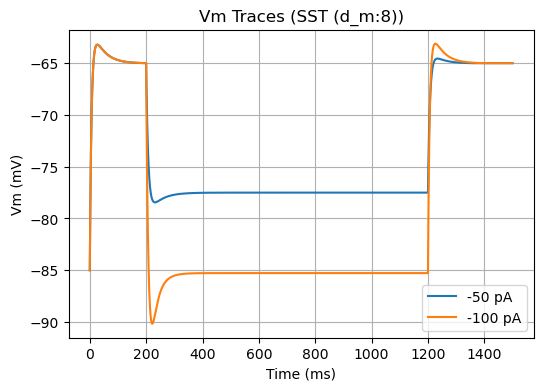

(<matplotlib.legend.Legend at 0x7f2ebe676950>, None, None)

In [8]:
# Simulation parameters
sim_params = {
    'stim_amp': -0.1,
    'stim_delay': 200,
    'stim_dur': 1000,
    'h_tstop': 1500,
    'h_dt': 0.025
    }
# Currents injected for each sim
# sim_amps = [0,-25,-50,-75,-100]
sim_amps = [-50,-100]

cell = _build_cell_legacy_compatible(cell_config_for_build)
looped_records = run_sim.looped_current_injection(cell,sim_params,sim_amps)

# Analyze and plot each run
plt.figure(figsize=(6,4))
for amp in sim_amps:
    print(f"{amp} pA spike frequency = {looped_records['F'][amp]:.2f} Hz")
    if amp <0:
        # print('Desired Properties:       R_in=98.9, tau1=5.9, tau2=??.?, sag_ratio=0.960, V_rest=-71.25')
        print(f"{ACTPassiveModule.compute_gpp(looped_records['V'][amp], h.dt, sim_params['stim_delay'], sim_params['stim_delay']+sim_params['stim_dur']-100, amp/1000)}\n")
    plt.plot(looped_records['T'][amp], looped_records['V'][amp], label=f"{amp} pA")
    
# Plot parameters
plt.xlabel("Time (ms)"), plt.ylabel("Vm (mV)"), plt.title(f"Vm Traces ({cell_name} (d_m:{soma_diam_multiplier}))")
# plt.xlim(45,50)
# plt.ylim(-97,-55)
plt.legend(),plt.grid(),plt.show()



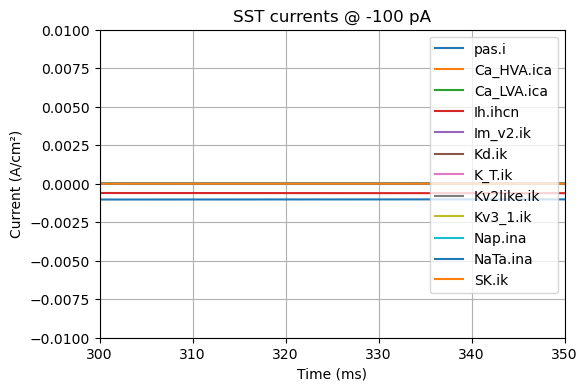

In [9]:
ampsel = sim_amps[-1]
currents = [
                    # 'pas.i', 
                    # # 'cadyn.i', 
                    # 'Ca_HVA.ica',
                    # 'Ca_LVA.ica',
                    # 'Ih.ihcn',
                    # 'Im_v2.ik', 
                    # 'Kd.ik',
                    # # 'K_T.ik',
                    # 'Kv2like.ik',
                    # 'Kv3_1.ik',
                    # 'Nap.ina',
                    # 'NaTa.ina',
                    # 'SK.ik',
                    ]
window = (300,350) #(1322,1325)

run_sim.plot_looped_currents(cell_name,ampsel,currents,looped_records,window)


# Tuning Active Properties

### 2. Multi-Sim Plot

Loaded Allen cell for 'SST' from manifest.json, soma_diam_multiplier=8.0, Vinit=-85.0
125 pA spike frequency = 0.00 Hz
150 pA spike frequency = 0.00 Hz
200 pA spike frequency = 0.00 Hz
300 pA spike frequency = 0.00 Hz


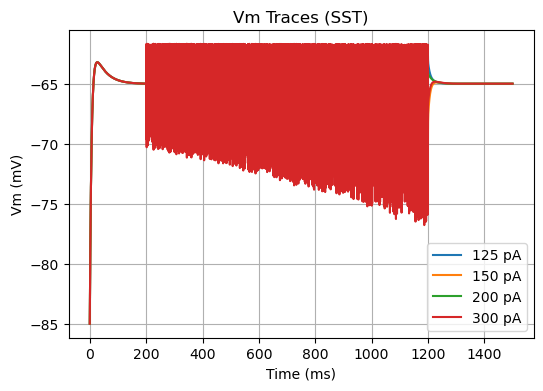

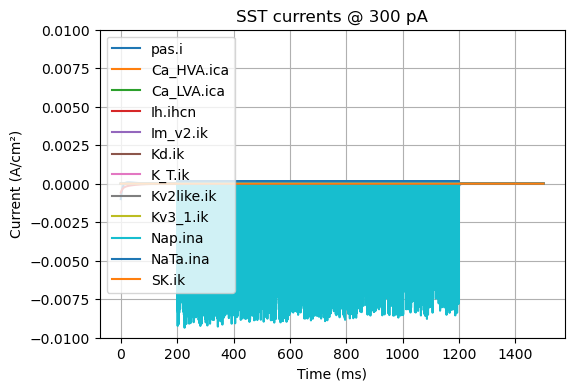

In [10]:
# Simulation parameters
sim_params = {
    'stim_amp': -0.1,
    'stim_delay': 200,
    'stim_dur': 1000,
    'h_tstop': 1500,
    'h_dt': 0.025
    }
# Currents injected for each sim
sim_amps = [125,150,200,300]

cell = _build_cell_legacy_compatible(cell_config_for_build)
looped_records = run_sim.looped_current_injection(cell,sim_params,sim_amps)

# Analyze and plot each run
plt.figure(figsize=(6,4))
for amp in sim_amps:
    print(f"{amp} pA spike frequency = {looped_records['F'][amp]:.2f} Hz")
    if amp <0:
        print(f"{ACTPassiveModule.compute_gpp(looped_records['V'][amp], h.dt, sim_params['stim_delay'], sim_params['stim_delay']+sim_params['stim_dur']-10, amp/1000)}\n")
    plt.plot(looped_records['T'][amp], looped_records['V'][amp], label=f"{amp} pA")
    
# Plot parameters
plt.xlabel("Time (ms)"), plt.ylabel("Vm (mV)"), plt.title(f"Vm Traces ({cell_name})")
window = (None,None)
plt.xlim(window[0],window[1])
# plt.ylim(-68.2,-67.8)
plt.legend(),plt.grid(),plt.show()


ampsel = sim_amps[-1]
currents = [] # add specific currents to list
run_sim.plot_looped_currents(cell_name,ampsel,currents,looped_records,window)


### 3. Generate FI Curve

Loaded Allen cell for 'SST' from manifest.json, soma_diam_multiplier=8.0, Vinit=-85.0


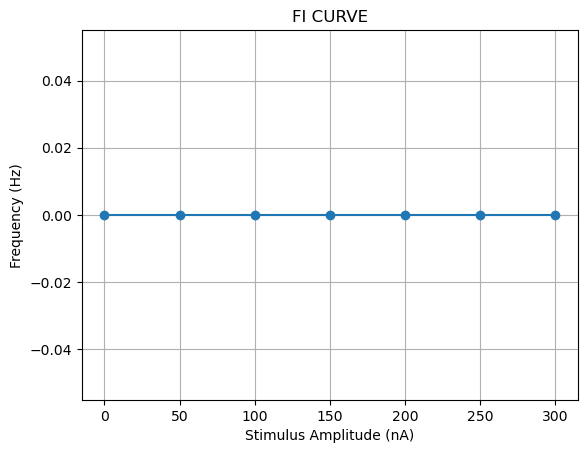

In [11]:
#set simulation parameters
sim_params = {
    'stim_amp': -0.1,
    'stim_delay': 200,
    'stim_dur': 1000,
    'h_tstop': 1500,
    'h_dt': 0.025
    }

#test the cell at multiple currents to get an FI curve
amp_range = (0, 300, 50) # (start, end, step)
amps = list(np.arange(amp_range[0], amp_range[1] + amp_range[2]/2, amp_range[2]))

cell = _build_cell_legacy_compatible(cell_config_for_build)
freq_recs = run_sim.run_FI(cell,sim_params,amps)


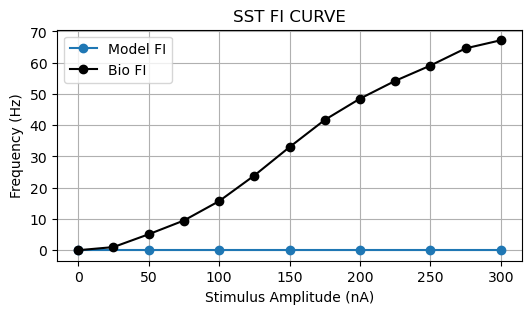

In [12]:
amps = [amp for amp in amps]
freqs = [freq_recs[amp] for amp in freq_recs]
bio_FI_data = {
    'SST': [(00,0),(25,1),(50,5.1),(75,9.5),(100,15.7),(125,23.9),(150,33),(175,41.7),(200,48.5),(225,54.2),(250,59.1),(275,64.6),(300,67.2)],
    'PV': [(00,0),(25,0),(50,0),(75,0.1),(100,3.3),(125,6.2),(150,12.9),(175,19.7),(200,27.9),(225,35.2),(250,44.8),(275,55.5),(300,57.4)]
}
if bio_FI_data[cell_name]:
    bio_FI = bio_FI_data[cell_name]
    bio_amps = []
    bio_freqs = []

    for FI in bio_FI:
        bio_amps.append(FI[0])
        bio_freqs.append(FI[1])


    plt.figure(figsize=(6,3))
    plt.plot(amps, freqs, marker='o', color = None,label = 'Model FI')
    plt.plot(bio_amps,bio_freqs,marker = 'o', color = 'k', label = 'Bio FI' )
    plt.title(f"{cell_name} FI CURVE")
    plt.xlabel("Stimulus Amplitude (nA)"),plt.ylabel("Frequency (Hz)")
    plt.legend(),plt.grid(),plt.show()